**This notebook illustrates the benefits of tensor rescaling and internals smoothing on a synthetic example.**

### Setup

In [1]:
# imports

import warnings; warnings.simplefilter('ignore')
from tqdm.notebook import tqdm
import plotting
colors = plotting.setup()

import jax, jax.numpy as jnp
jnp.set_printoptions(precision=3, suppress=True)

from decoupling import Algorithm
from decoupling.scaler import JacobianScaler
from decoupling.utils import function_error, collect_information_from_random

In [2]:
# constants

KEY_TRAIN = jax.random.key(0)
KEY_TEST = jax.random.key(1)

RANK = 4
NSEEDS = 10
NSIGMAS = 100
NSAMPLES = 100

LAMBDAS = jnp.linspace(0.0, 1000.0, num=512)
print(LAMBDAS[:5], '...', LAMBDAS[-5:])

[0.    1.957 3.914 5.871 7.828] ... [ 992.172  994.129  996.086  998.043 1000.   ]


In [3]:
# target function

def make_target(sigma: float):
    def target(x):
        x1, x2 = x
        return jnp.asarray([
            sigma*(jnp.cos(4 * jnp.pi * x1) + x2**2),
            -jnp.sin(3 * jnp.pi * x2) + x1**3,
        ])
    return target

### Scaling: Per-Output Errors 

In [4]:
def compare_errors(sigmas, scale: bool):
    errors = []
    missed = 0

    for sigma in tqdm(sigmas):
        target = make_target(sigma)

        mean_errors = jnp.zeros(2)
        count = 0

        (X_train, Y_train, J_train) = collect_information_from_random(
            target, NSAMPLES, 2, KEY_TRAIN)

        (X_test, Y_test, _) = collect_information_from_random(
            target, NSAMPLES, 2, KEY_TEST)

        if scale:
            scaler = JacobianScaler(J_train)
            J_train, Y_train = scaler.scale(J_train, Y_train)

        for key in jax.random.split(KEY_TRAIN, NSEEDS):
            try:
                algorithm = Algorithm(RANK, key, use_smoothing=False, show_progress=False)
                decoupling = algorithm.run(X_train, Y_train, J_train)
            
                if scale: decoupling = scaler.unscale(decoupling)

                Y_preds = jax.vmap(decoupling)(X_test)
                mean_errors += function_error(Y_test, Y_preds)
                count += 1

            except RuntimeError: missed += 1

        errors.append(mean_errors / count)

    print(f'missed {missed} / {NSEEDS*len(sigmas)}')
    return jnp.stack(errors)

In [5]:
sigmas1 = jnp.logspace(0.0, 2.5, NSIGMAS)
sigmas1[-5:]

Array([250.605, 265.609, 281.511, 298.365, 316.228], dtype=float32)

In [6]:
errors_before = compare_errors(sigmas1, scale=False)

  0%|          | 0/100 [00:00<?, ?it/s]

missed 27 / 1000


In [7]:
errors_after = compare_errors(sigmas1, scale=True)

  0%|          | 0/100 [00:00<?, ?it/s]

missed 0 / 1000


### Scaling: Condition Numbers

In [8]:
def compare_rconds(sigmas, scale):
    rconds = {'W': [], 'V': [], 'H': [], 'R': []}
    missed = 0

    for sigma in tqdm(sigmas):
        target = make_target(sigma)
        
        rcV = rcW = rcH = rcR = 0.0
        count = 0

        (X, Y, J) = collect_information_from_random(target, NSAMPLES, 2, KEY_TRAIN)

        if scale:
            scaler = JacobianScaler(J)
            J, Y = scaler.scale(J, Y)

        for key in jax.random.split(KEY_TRAIN, NSEEDS):
            try:
                algorithm = Algorithm(RANK, key, use_smoothing=False, show_progress=False)
                decoupling = algorithm.run(X, Y, J)
                
                rcW += jnp.median(algorithm.info.rconds['W'])
                rcV += jnp.median(algorithm.info.rconds['V'])
                rcH += jnp.median(algorithm.info.rconds['H'])
                rcR += jnp.median(algorithm.info.rconds['R'])
                
                count += 1

            except RuntimeError: missed += 1

        rconds['W'].append(float(rcW) / count)
        rconds['V'].append(float(rcV) / count)
        rconds['H'].append(float(rcH) / count)
        rconds['R'].append(float(rcR) / count)

    print(f'missed {missed} / {NSEEDS*len(sigmas)}')
    return rconds

In [9]:
sigmas2 = jnp.logspace(0, 6, NSIGMAS)
sigmas2[-3:]

Array([7.565e+05, 8.697e+05, 1.000e+06], dtype=float32)

In [10]:
rconds_before = compare_rconds(sigmas2, scale=False)

  0%|          | 0/100 [00:00<?, ?it/s]

missed 20 / 1000


In [11]:
rconds_after = compare_rconds(sigmas2, scale=True)

  0%|          | 0/100 [00:00<?, ?it/s]

missed 0 / 1000


plot saved at /home/maxime/Programming/ICASSP.2027/plots/before.pdf


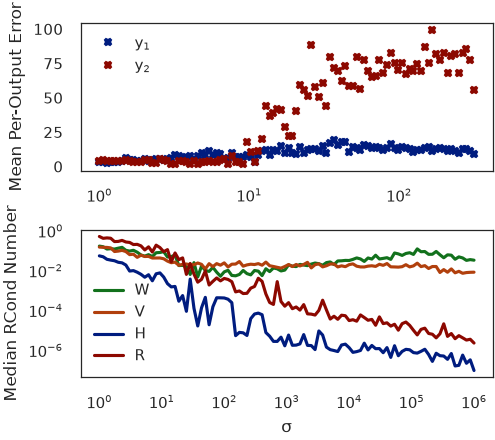

In [12]:
plotting.plot_before(sigmas1, sigmas2, errors_before, rconds_before, colors)

plot saved at /home/maxime/Programming/ICASSP.2027/plots/after.pdf


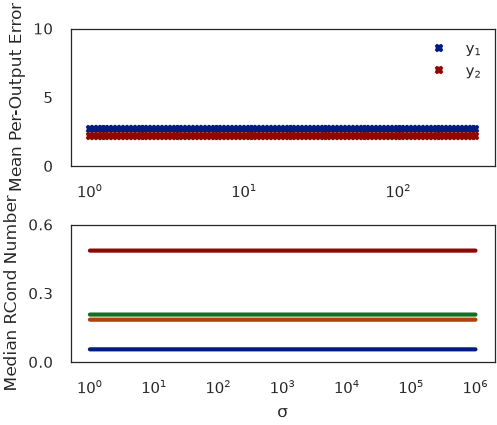

In [13]:
plotting.plot_after(sigmas1, sigmas2, errors_after, rconds_after, colors)

### Smoothing

In [14]:
def compare_smoothing(dofs, smoothing: bool):
    errors = []
    missed = 0
    
    target = make_target(1.0)
    (X_train, Y_train, J_train) = collect_information_from_random(target, NSAMPLES, 2, KEY_TRAIN)
    (X_test, Y_test, _) = collect_information_from_random(target, NSAMPLES, 2, KEY_TEST)

    for dof in tqdm(dofs):
        mean_errors = jnp.zeros(2)
        count = 0
        
        for key in jax.random.split(KEY_TRAIN, NSEEDS):
            try:
                algorithm = Algorithm(
                    rank=RANK,
                    key=key, 
                    use_smoothing=smoothing, 
                    show_progress=False,
                    splines_dof=int(dof),
                    smoothing_grid=LAMBDAS,
                )
                
                decoupling = algorithm.run(X_train, Y_train, J_train)
                
                Y_preds = jax.vmap(decoupling)(X_test)
                
                mean_errors += function_error(Y_test, Y_preds)
                count += 1

            except RuntimeError: missed += 1
                
        mean_errors = mean_errors / count
        errors.append(mean_errors)

    print(f'missed {missed} / {NSEEDS*len(dofs)}')
    return jnp.stack(errors)

In [15]:
dofs = jnp.arange(10, NSAMPLES+1, 1, dtype=jnp.int_)
dofs

Array([ 10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,
        23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35,
        36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,
        49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,
        62,  63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,
        75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,
        88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100],      dtype=int32)

In [16]:
errors_nosmoothing = compare_smoothing(dofs, smoothing=False)

  0%|          | 0/91 [00:00<?, ?it/s]

missed 0 / 910


In [17]:
errors_smoothing = compare_smoothing(dofs, smoothing=True)

  0%|          | 0/91 [00:00<?, ?it/s]

missed 0 / 910


plot saved at /home/maxime/Programming/ICASSP.2027/plots/smoothing1.pdf


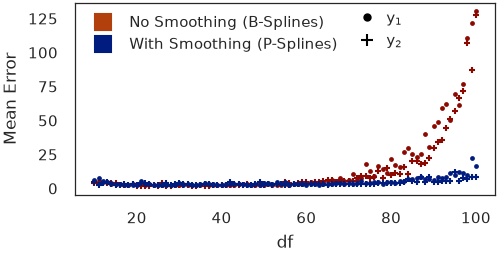

In [18]:
plotting.plot_smoothing1(dofs, errors_nosmoothing, errors_smoothing, colors)

plot saved at /home/maxime/Programming/ICASSP.2027/plots/smoothing2.pdf


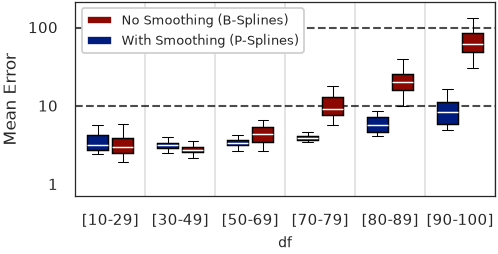

In [19]:
plotting.plot_smoothing2(dofs, errors_nosmoothing, errors_smoothing, colors)